# Notebook 1 — Data Loading, Cleaning & Exploratory Analysis
### LLM-Augmented Big-Data Dengue Outbreak Forecasting and Risk Reasoning in Bangladesh

**Purpose of this notebook:**
1. Mount Google Drive and load the two raw datasets
2. Detect and fix known data-quality issues (division-name mismatches, invalid ISO weeks, city-name mismatches)
3. Build clean, analysis-ready tables at annual / monthly / weekly / division level
4. Produce the core EDA tables and figures for the Q1 research write-up (dataset description, seasonality, division risk, weather association)
5. Save cleaned + merged CSVs to Drive so **Notebook 2 (baseline + deep learning forecasting models)** can load them directly

---

## 0. Google Drive folder setup

Set **`BASE_DIR`** below to a single Drive folder that contains, somewhere inside it, both:
- the extracted dengue repo (wherever `dengue_annual_national.csv` etc. end up, e.g. `data/raw/`)
- the weather CSV `bangladesh_weather_2016_2025.csv` (however it's nested, e.g. inside an `archive (3)/` folder)

The next cell **auto-searches every subfolder of `BASE_DIR`** for the exact filenames it needs and prints what it found, so you don't have to match an exact folder layout — you just need everything to live somewhere under `BASE_DIR`. If a file shows as `MISSING`, double-check it was actually extracted (not left zipped) inside `BASE_DIR`.


In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import os
import glob

# ---- EDIT THIS: the single Drive folder that CONTAINS both your dengue repo folder and your weather data ----
BASE_DIR = '/content/drive/MyDrive/My Work/Research/Medical_sector/Dengue/dataset'
# ----------------------------------------------------------------------------------------------------------

OUTPUT_DIR = os.path.join(BASE_DIR, 'processed')   # cleaned files go here for Notebook 2
FIG_DIR    = os.path.join(BASE_DIR, 'figures')
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

def find_file(base_dir, filename):
    """Recursively search base_dir for filename (handles the two datasets sitting in
    different subfolders / different nesting than expected). Returns the first match or None."""
    matches = glob.glob(os.path.join(base_dir, '**', filename), recursive=True)
    return matches[0] if matches else None

# --- Auto-locate the 6 dengue raw CSVs, wherever the repo was actually extracted ---
dengue_filenames = [
    'dengue_annual_national.csv', 'dengue_monthly_national.csv', 'dengue_weekly_national.csv',
    'dengue_daily_2026.csv', 'dengue_division_2026.csv', 'dengue_weekly_division_2026.csv',
]

dengue_paths = {}
print('--- Dengue files ---')
for fn in dengue_filenames:
    path = find_file(BASE_DIR, fn)
    dengue_paths[fn] = path
    print(f"{'FOUND  ' if path else 'MISSING'} {fn:36s} {path or ''}")

# --- Auto-locate the weather CSV, wherever it actually sits (e.g. an 'archive (3)' folder) ---
weather_path = find_file(BASE_DIR, 'bangladesh_weather_2016_2025.csv')
print('\n--- Weather file ---')
print(f"{'FOUND  ' if weather_path else 'MISSING'} bangladesh_weather_2016_2025.csv   {weather_path or ''}")

missing = [fn for fn, p in dengue_paths.items() if p is None]
assert not missing, f'Could not find these files anywhere under BASE_DIR: {missing}. Check BASE_DIR and that the files were uploaded/extracted into Drive.'
assert weather_path is not None, 'Could not find the weather CSV anywhere under BASE_DIR. Check BASE_DIR and that the weather archive was extracted into Drive.'


--- Dengue files ---
FOUND   dengue_annual_national.csv           /content/drive/MyDrive/My Work/Research/Medical_sector/Dengue/dataset/bangladesh-dengue-2018-2025-main/data/raw/dengue_annual_national.csv
FOUND   dengue_monthly_national.csv          /content/drive/MyDrive/My Work/Research/Medical_sector/Dengue/dataset/bangladesh-dengue-2018-2025-main/data/raw/dengue_monthly_national.csv
FOUND   dengue_weekly_national.csv           /content/drive/MyDrive/My Work/Research/Medical_sector/Dengue/dataset/bangladesh-dengue-2018-2025-main/data/raw/dengue_weekly_national.csv
FOUND   dengue_daily_2026.csv                /content/drive/MyDrive/My Work/Research/Medical_sector/Dengue/dataset/bangladesh-dengue-2018-2025-main/data/raw/dengue_daily_2026.csv
FOUND   dengue_division_2026.csv             /content/drive/MyDrive/My Work/Research/Medical_sector/Dengue/dataset/bangladesh-dengue-2018-2025-main/data/raw/dengue_division_2026.csv
FOUND   dengue_weekly_division_2026.csv      /content/drive/MyDri

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 110
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

SAVE_FIGS = True  # set False to skip writing PNGs to Drive


## 1. Load raw data

In [4]:
dengue_files = {
    'annual':               'dengue_annual_national.csv',
    'monthly':               'dengue_monthly_national.csv',
    'weekly':                'dengue_weekly_national.csv',
    'daily_2026':             'dengue_daily_2026.csv',
    'division_2026':          'dengue_division_2026.csv',
    'weekly_division_2026':   'dengue_weekly_division_2026.csv',
}

dengue = {name: pd.read_csv(dengue_paths[fname]) for name, fname in dengue_files.items()}

print(f"{'dataset':<24}{'rows':>8}   columns")
for name, df in dengue.items():
    print(f"{name:<24}{len(df):>8}   {list(df.columns)}")


dataset                     rows   columns
annual                         9   ['year', 'dengue_cases']
monthly                       36   ['year', 'month', 'month_num', 'dengue_cases']
weekly                       159   ['year', 'week', 'week_num', 'dengue_cases']
daily_2026                   154   ['date', 'dengue_cases_daily']
division_2026                  9   ['year', 'division', 'dengue_cases_cumulative', 'dengue_deaths_cumulative']
weekly_division_2026         176   ['year', 'week', 'week_num', 'division', 'dengue_cases']


In [5]:
weather = pd.read_csv(weather_path)
weather['time'] = pd.to_datetime(weather['time'])

print('Weather shape:', weather.shape)
print('Cities:', sorted(weather['city'].unique()))
print('Date range:', weather['time'].min(), '->', weather['time'].max())
weather.head()


Weather shape: (350880, 10)
Cities: ['Chittagong', 'Dhaka', 'Rajshahi', 'Sylhet']
Date range: 2015-12-31 00:00:00 -> 2026-01-01 23:00:00


,time,temperature_2m,relative_humidity_2m,rain,pressure_msl,cloud_cover,wind_speed_100m,wind_direction_100m,soil_temperature_100_to_255cm,city
0,2015-12-31 00:00:00,14.0,96,0.0,1017.6,77,11.2,2,24.7,Dhaka
1,2015-12-31 01:00:00,14.0,96,0.0,1017.3,79,12.0,7,24.7,Dhaka
2,2015-12-31 02:00:00,13.4,95,0.0,1017.1,91,12.5,18,24.7,Dhaka
3,2015-12-31 03:00:00,13.6,95,0.0,1017.0,90,12.4,26,24.7,Dhaka
4,2015-12-31 04:00:00,13.6,97,0.0,1016.7,99,11.2,50,24.7,Dhaka


## 2. Data-quality checks and cleaning

Three known issues were identified by manually inspecting these files before this notebook was written. We detect and fix each one explicitly (rather than silently) so the cleaning is auditable in the eventual paper's methods section.

1. **Division-name mismatches** — `dengue_division_2026.csv` and `dengue_weekly_division_2026.csv` spell divisions inconsistently ("Barisal" vs "Barishal"), and `dengue_division_2026.csv` contains a typo row `"Raishahi"` that duplicates `"Rajshahi"`.
2. **Invalid ISO weeks** — `dengue_weekly_national.csv` contains weeks W53–W55 for 2025, which do not exist (an ISO year has at most 53 weeks; 2025 has 52). This is a scrape/date-boundary artifact.
3. **City-name mismatch across datasets** — the weather file uses the old name **"Chittagong"**; the dengue files use the current official name **"Chattogram"**.


In [6]:
print('division_2026 raw divisions:       ', sorted(dengue['division_2026']['division'].unique()))
print('weekly_division_2026 raw divisions:', sorted(dengue['weekly_division_2026']['division'].unique()))


division_2026 raw divisions:        ['Barishal', 'Chattogram', 'Dhaka', 'Khulna', 'Mymensingh', 'Raishahi', 'Rajshahi', 'Rangpur', 'Sylhet']
weekly_division_2026 raw divisions: ['Barisal', 'Chattogram', 'Dhaka', 'Khulna', 'Mymensingh', 'Rajshahi', 'Rangpur', 'Sylhet']


In [7]:
# --- Fix 1: standardize division names to the 8 official divisions ---
division_map = {
    'Barisal': 'Barishal', 'Barishal': 'Barishal',
    'Chattogram': 'Chattogram', 'Chittagong': 'Chattogram',
    'Dhaka': 'Dhaka',
    'Khulna': 'Khulna',
    'Mymensingh': 'Mymensingh',
    'Rajshahi': 'Rajshahi', 'Raishahi': 'Rajshahi',   # typo fix
    'Rangpur': 'Rangpur',
    'Sylhet': 'Sylhet',
}

dengue['division_2026']['division'] = dengue['division_2026']['division'].map(division_map)
dengue['weekly_division_2026']['division'] = dengue['weekly_division_2026']['division'].map(division_map)

assert dengue['division_2026']['division'].isnull().sum() == 0, 'Unmapped division found!'
assert dengue['weekly_division_2026']['division'].isnull().sum() == 0, 'Unmapped division found!'

# The typo row created a duplicate Rajshahi entry -> collapse by summing
dengue['division_2026'] = (
    dengue['division_2026']
    .groupby(['year', 'division'], as_index=False)[['dengue_cases_cumulative', 'dengue_deaths_cumulative']]
    .sum()
)

print('Cleaned division_2026:')
dengue['division_2026'].sort_values('dengue_cases_cumulative', ascending=False)


Cleaned division_2026:


,year,division,dengue_cases_cumulative,dengue_deaths_cumulative
2,2026,Dhaka,1275,3
0,2026,Barishal,833,0
1,2026,Chattogram,772,1
3,2026,Khulna,271,1
5,2026,Rajshahi,133,1
4,2026,Mymensingh,105,0
7,2026,Sylhet,35,0
6,2026,Rangpur,29,0


In [8]:
# --- Fix 2: drop invalid ISO weeks (W53-W55, 2025) ---
w = dengue['weekly']
bad_weeks = w[(w['year'] == 2025) & (w['week_num'] > 52)]
print('Rows flagged as invalid ISO weeks:')
print(bad_weeks)

dengue['weekly'] = w[~((w['year'] == 2025) & (w['week_num'] > 52))].reset_index(drop=True)
print('\nWeekly national rows after cleaning:', dengue['weekly'].shape)


Rows flagged as invalid ISO weeks:
     year week  week_num  dengue_cases
156  2025  W53        53          1507
157  2025  W54        54           851
158  2025  W55        55           413

Weekly national rows after cleaning: (156, 4)


In [9]:
# --- Fix 3: align city naming in weather data with dengue division naming ---
weather['city'] = weather['city'].replace({'Chittagong': 'Chattogram'})
print(sorted(weather['city'].unique()))


['Chattogram', 'Dhaka', 'Rajshahi', 'Sylhet']


## 3. Build proper date columns (ISO week -> calendar date, month -> calendar date)

In [10]:
def iso_week_to_monday(year, week_num):
    return pd.to_datetime(f'{int(year)}-W{int(week_num):02d}-1', format='%G-W%V-%u')

dengue['weekly']['week_start'] = dengue['weekly'].apply(
    lambda r: iso_week_to_monday(r['year'], r['week_num']), axis=1)

dengue['weekly_division_2026']['week_start'] = dengue['weekly_division_2026'].apply(
    lambda r: iso_week_to_monday(r['year'], r['week_num']), axis=1)

dengue['monthly']['month_start'] = pd.to_datetime(
    dengue['monthly']['year'].astype(str) + '-' + dengue['monthly']['month_num'].astype(str) + '-01')

dengue['daily_2026']['date'] = pd.to_datetime(dengue['daily_2026']['date'])

print('Date columns added. Sample:')
dengue['weekly'][['year', 'week', 'week_num', 'week_start', 'dengue_cases']].head()


Date columns added. Sample:


,year,week,week_num,week_start,dengue_cases
0,2023,W01,1,2023-01-02,105
1,2023,W02,2,2023-01-09,56
2,2023,W03,3,2023-01-16,51
3,2023,W04,4,2023-01-23,26
4,2023,W05,5,2023-01-30,30


## 4. Table & Figure 1 — Annual national trend (2018–2026)

This is the headline epidemiological context table/figure for the paper's introduction: it shows the record 2023 outbreak, the 2020 COVID-lockdown dip, and the partial-year 2026 figure.

In [12]:
import os

table1 = dengue['annual'].copy()
table1['note'] = ''
table1.loc[table1['year'] == 2020, 'note'] = 'COVID-19 lockdown year'
table1.loc[table1['year'] == 2023, 'note'] = 'Record outbreak year'
table1.loc[table1['year'] == 2026, 'note'] = 'Partial year (data through scrape date)'

print('Table 1. Annual reported (admitted/hospitalised) dengue cases, Bangladesh, 2018-2026')
display(table1)

# Ensure the directory exists before saving
os.makedirs(FIG_DIR, exist_ok=True)
table1.to_csv(os.path.join(FIG_DIR, 'table1_annual_summary.csv'), index=False)

Table 1. Annual reported (admitted/hospitalised) dengue cases, Bangladesh, 2018-2026


,year,dengue_cases,note
0,2018,10148,
1,2019,101354,
2,2020,1405,COVID-19 lockdown year
3,2021,28429,
4,2022,62382,
5,2023,321017,Record outbreak year
6,2024,101211,
7,2025,102861,
8,2026,3459,Partial year (data through scrape date)


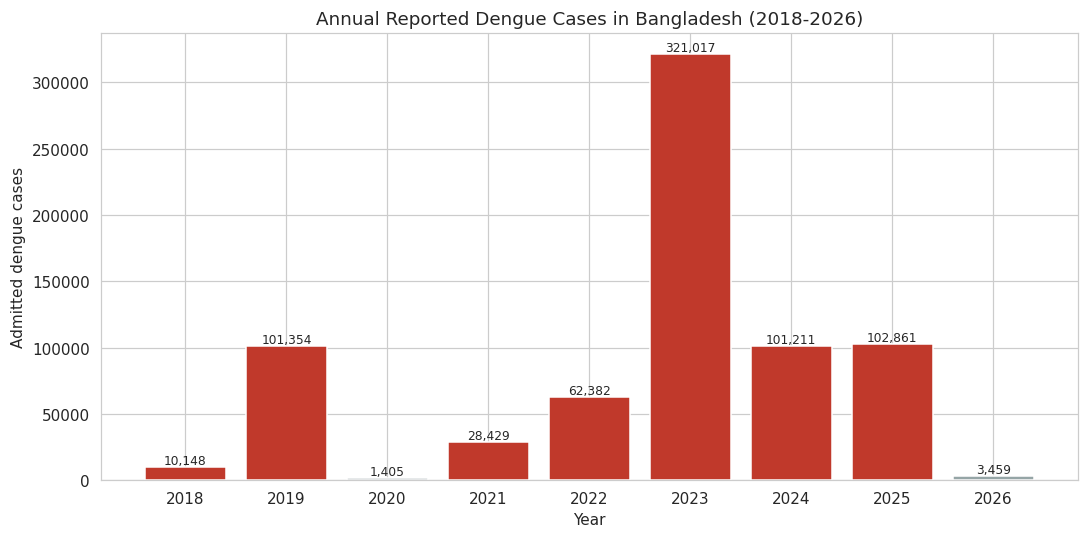

In [22]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#c0392b' if y not in (2020, 2026) else '#95a5a6' for y in table1['year']]
bars = ax.bar(table1['year'].astype(str), table1['dengue_cases'], color=colors)

for b in bars:
    ax.annotate(f'{int(b.get_height()):,}', (b.get_x() + b.get_width() / 2, b.get_height()),
                ha='center', va='bottom', fontsize=8, rotation=0)

ax.set_title('Annual Reported Dengue Cases in Bangladesh (2018-2026)')
ax.set_xlabel('Year')
ax.set_ylabel('Admitted dengue cases')
plt.tight_layout()
if SAVE_FIGS:
    plt.savefig(os.path.join(FIG_DIR, 'fig1_annual_trend.png'), dpi=150)
plt.show()


## 5. Table & Figure 2 — Weekly epidemic curves by year (2023-2025)

Shows the seasonal shape of the outbreak (typical monsoon-season peak, roughly weeks 30-45) and how sharply 2023 deviated from 2024/2025.

In [14]:
table2 = (
    dengue['weekly']
    .pivot_table(index='week_num', columns='year', values='dengue_cases')
    .round(0)
)
print('Table 2. Weekly dengue cases by year (rows = ISO week number)')
display(table2)
table2.to_csv(os.path.join(FIG_DIR, 'table2_weekly_by_year.csv'))


Table 2. Weekly dengue cases by year (rows = ISO week number)


year,2023,2024,2025
week_num,,,
1,105.0,362.0,0.0
2,56.0,267.0,221.0
3,51.0,189.0,352.0
4,26.0,160.0,258.0
5,30.0,112.0,190.0
6,25.0,117.0,149.0
7,22.0,61.0,88.0
8,14.0,59.0,127.0
9,14.0,77.0,99.0


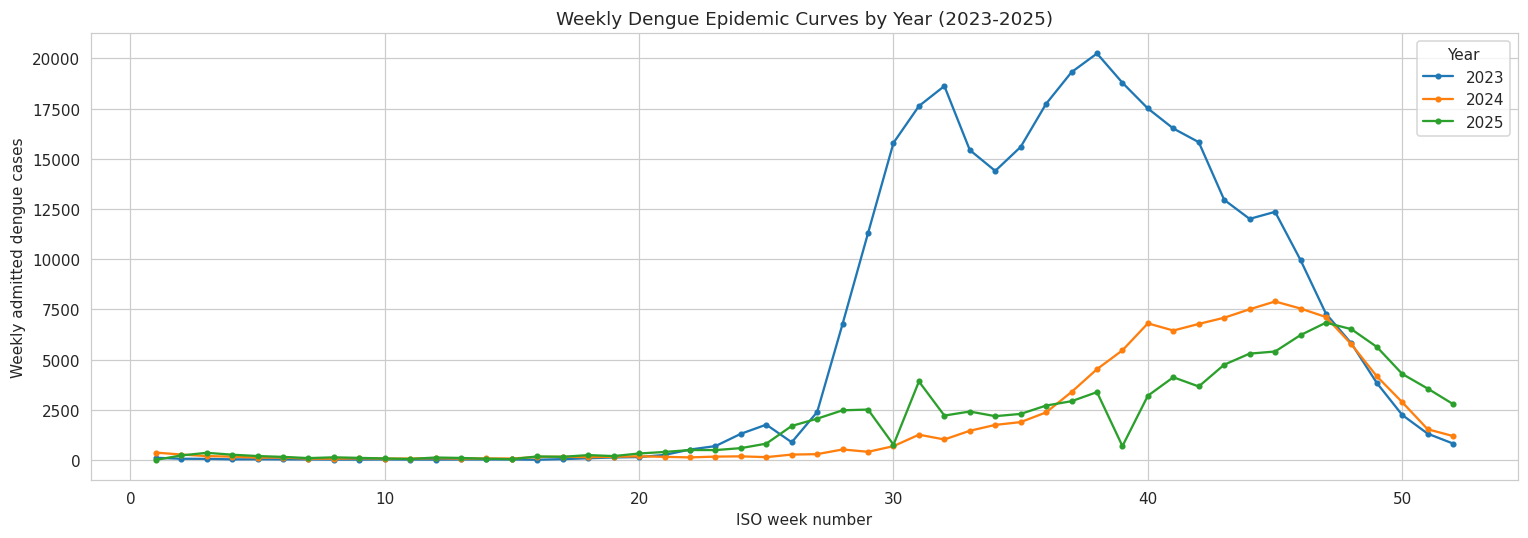

In [21]:
fig, ax = plt.subplots(figsize=(14, 5))
for yr, grp in dengue['weekly'].groupby('year'):
    ax.plot(grp['week_num'], grp['dengue_cases'], marker='o', markersize=3, linewidth=1.5, label=str(yr))

ax.set_title('Weekly Dengue Epidemic Curves by Year (2023-2025)')
ax.set_xlabel('ISO week number')
ax.set_ylabel('Weekly admitted dengue cases')
ax.legend(title='Year')
plt.tight_layout()
if SAVE_FIGS:
    plt.savefig(os.path.join(FIG_DIR, 'fig2_weekly_epidemic_curve.png'), dpi=150)
plt.show()


## 6. Table & Figure 3 — Monthly seasonality heatmap (2023-2025)

In [16]:
table3 = dengue['monthly'].pivot(index='year', columns='month_num', values='dengue_cases')
table3.columns = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'][:len(table3.columns)]

print('Table 3. Monthly dengue cases by year')
display(table3)
table3.to_csv(os.path.join(FIG_DIR, 'table3_monthly_seasonality.csv'))


Table 3. Monthly dengue cases by year


,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
year,,,,,,,,,,,,
2023,253,81,76,95,855,4665,41891,72318,79994,68128,40990,9371
2024,1052,339,311,504,644,798,2669,6521,18097,30879,29652,9745
2025,6,1161,374,336,701,1773,5949,10684,10496,15862,22520,24535


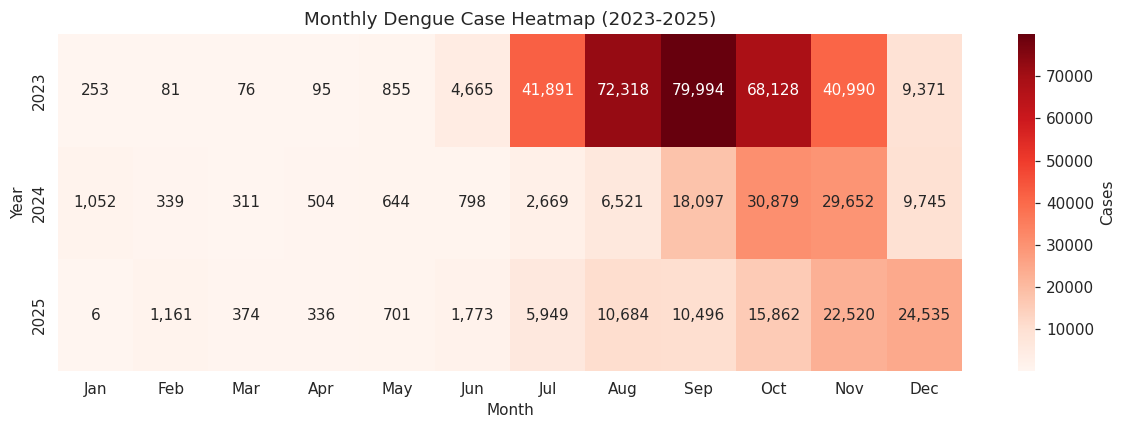

In [20]:
fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(table3, annot=True, fmt=',.0f', cmap='Reds', cbar_kws={'label': 'Cases'}, ax=ax)
ax.set_title('Monthly Dengue Case Heatmap (2023-2025)')
ax.set_xlabel('Month')
ax.set_ylabel('Year')
plt.tight_layout()
if SAVE_FIGS:
    plt.savefig(os.path.join(FIG_DIR, 'fig3_monthly_heatmap.png'), dpi=150)
plt.show()


## 7. Table & Figure 4 — Division-level risk (2026 YTD)

**Caveat to state explicitly in the paper:** division-level granularity is currently only available for 2026 (partial year). This table/figure is descriptive context, not a basis for a trained regional forecasting model — see the scoping note in the markdown cell at the end of this notebook.

In [18]:
table4 = dengue['division_2026'].sort_values('dengue_cases_cumulative', ascending=False).reset_index(drop=True)
table4['case_fatality_rate_%'] = (table4['dengue_deaths_cumulative'] / table4['dengue_cases_cumulative'] * 100).round(2)

print('Table 4. Cumulative dengue cases and deaths by division, 2026 (YTD)')
display(table4)
table4.to_csv(os.path.join(FIG_DIR, 'table4_division_2026.csv'), index=False)


Table 4. Cumulative dengue cases and deaths by division, 2026 (YTD)


,year,division,dengue_cases_cumulative,dengue_deaths_cumulative,case_fatality_rate_%
0,2026,Dhaka,1275,3,0.24
1,2026,Barishal,833,0,0.00
2,2026,Chattogram,772,1,0.13
3,2026,Khulna,271,1,0.37
4,2026,Rajshahi,133,1,0.75
5,2026,Mymensingh,105,0,0.00
6,2026,Sylhet,35,0,0.00
7,2026,Rangpur,29,0,0.00


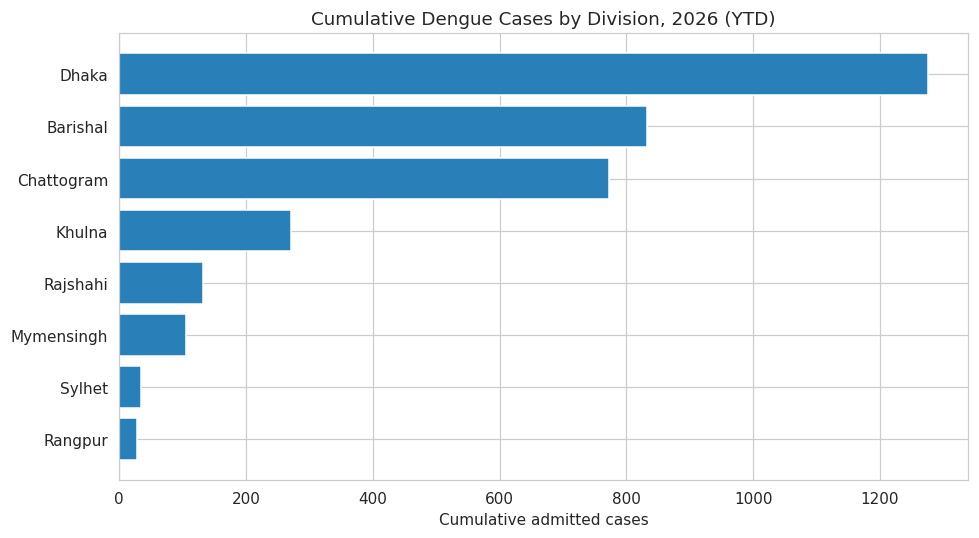

In [23]:
fig, ax = plt.subplots(figsize=(9, 5))
order = table4.sort_values('dengue_cases_cumulative')
ax.barh(order['division'], order['dengue_cases_cumulative'], color='#2980b9')
ax.set_title('Cumulative Dengue Cases by Division, 2026 (YTD)')
ax.set_xlabel('Cumulative admitted cases')
plt.tight_layout()
if SAVE_FIGS:
    plt.savefig(os.path.join(FIG_DIR, 'fig4_division_2026.png'), dpi=150)
plt.show()


## 8. Table & Figure 5 — Weather summary by city (2016-2025)

In [24]:
table5 = (
    weather
    .groupby('city')[['temperature_2m', 'relative_humidity_2m', 'rain', 'wind_speed_100m']]
    .agg(['mean', 'std', 'min', 'max'])
    .round(2)
)
print('Table 5. Hourly weather variable summary statistics by city (2016-2025)')
display(table5)
table5.to_csv(os.path.join(FIG_DIR, 'table5_weather_summary.csv'))


Table 5. Hourly weather variable summary statistics by city (2016-2025)


temperature_2m                   relative_humidity_2m                  rain                   \
                     mean   std   min   max                 mean    std min  max  mean   std  min   max   
city                                                                                                      
Chattogram          25.98  3.91  12.3  36.5                80.82  11.49  29  100  0.28  0.88  0.0  27.1   
Dhaka               25.89  5.23   8.6  40.2                80.29  14.59  21  100  0.21  0.83  0.0  26.8   
Rajshahi            25.96  5.62   7.5  41.8                78.21  14.97  10  100  0.17  0.73  0.0  29.5   
Sylhet              25.09  5.13   7.1  38.7                82.22  13.00  21  100  0.50  1.24  0.0  32.5   

           wind_speed_100m                   
                      mean   std  min   max  
city                                         
Chattogram           16.59  8.46  0.0  70.7  
Dhaka                14.23  7.34  0.0  80.3  
Rajshahi             14.20  6.82  0.0  74.2  
Sylhet                6.81  3.86  0.0  68.4

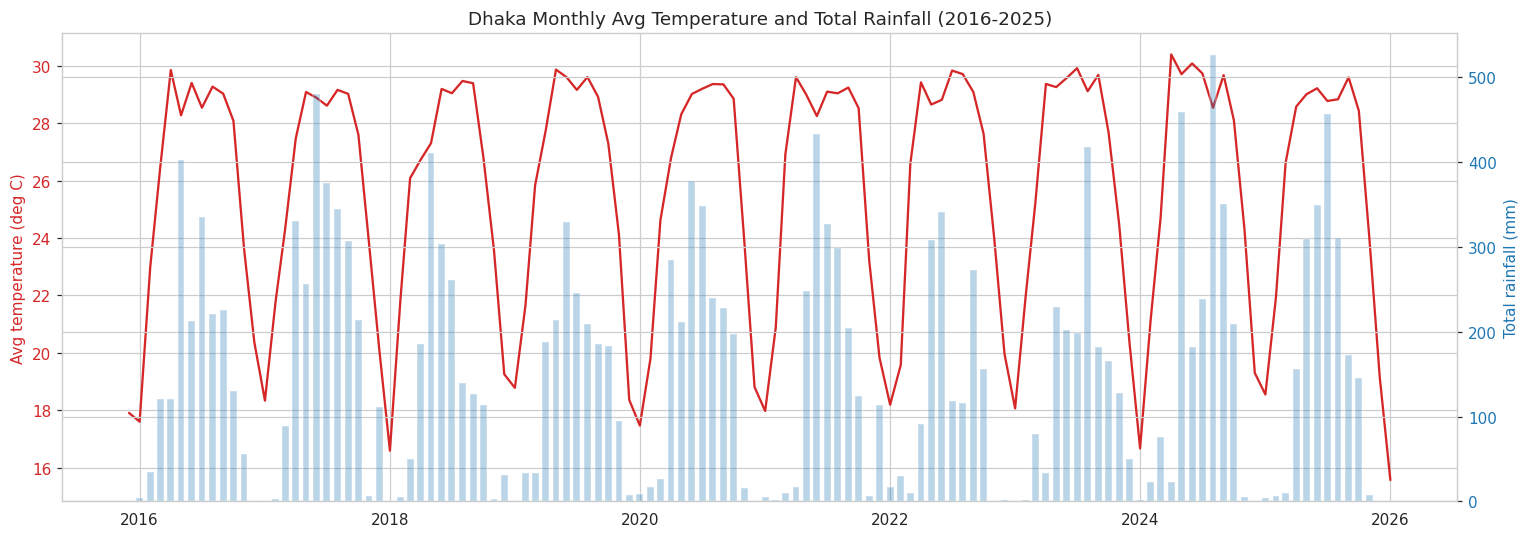

In [25]:
dhaka = weather[weather['city'] == 'Dhaka'].copy()
dhaka['month'] = dhaka['time'].dt.to_period('M')
monthly_w = dhaka.groupby('month').agg(avg_temp=('temperature_2m', 'mean'),
                                        total_rain=('rain', 'sum')).reset_index()
monthly_w['month'] = monthly_w['month'].dt.to_timestamp()

fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(monthly_w['month'], monthly_w['avg_temp'], color='tab:red', label='Avg temperature (deg C)')
ax1.set_ylabel('Avg temperature (deg C)', color='tab:red')
ax1.tick_params(axis='y', labelcolor='tab:red')

ax2 = ax1.twinx()
ax2.bar(monthly_w['month'], monthly_w['total_rain'], color='tab:blue', alpha=0.3, width=20, label='Total rainfall (mm)')
ax2.set_ylabel('Total rainfall (mm)', color='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:blue')

ax1.set_title('Dhaka Monthly Avg Temperature and Total Rainfall (2016-2025)')
plt.tight_layout()
if SAVE_FIGS:
    plt.savefig(os.path.join(FIG_DIR, 'fig5_dhaka_monthly_weather.png'), dpi=150)
plt.show()


## 9. Merge weekly national dengue with weekly national weather (2023-2025)

Weather is averaged across the 4 available cities to build a simple national-level weekly weather signal that aligns with the dengue data's finest continuous national resolution.

In [26]:
iso = weather['time'].dt.isocalendar()
weather['iso_year'] = iso['year']
weather['iso_week'] = iso['week']

weekly_weather = (
    weather
    .groupby(['iso_year', 'iso_week'])
    .agg(avg_temp=('temperature_2m', 'mean'),
         max_temp=('temperature_2m', 'max'),
         avg_humidity=('relative_humidity_2m', 'mean'),
         total_rain=('rain', 'sum'),
         avg_wind=('wind_speed_100m', 'mean'),
         avg_cloud=('cloud_cover', 'mean'))
    .reset_index()
    .rename(columns={'iso_year': 'year', 'iso_week': 'week_num'})
)

merged = dengue['weekly'].merge(weekly_weather, on=['year', 'week_num'], how='inner')
merged = merged.sort_values('week_start').reset_index(drop=True)

print('Merged weekly dengue + weather shape:', merged.shape)
merged.head()


Merged weekly dengue + weather shape: (156, 11)


,year,week,week_num,dengue_cases,week_start,avg_temp,max_temp,avg_humidity,total_rain,avg_wind,avg_cloud
0,2023,W01,1,105,2023-01-02,16.905655,25.8,83.145833,0.0,13.430208,12.727679
1,2023,W02,2,56,2023-01-09,18.255952,27.5,78.358631,0.4,10.272768,9.791667
2,2023,W03,3,51,2023-01-16,17.161310,27.0,74.822917,0.1,11.238244,8.839286
3,2023,W04,4,26,2023-01-23,20.358036,28.4,78.227679,0.0,11.679315,6.046131
4,2023,W05,5,30,2023-01-30,20.445089,29.6,76.255952,0.0,12.872619,20.915179


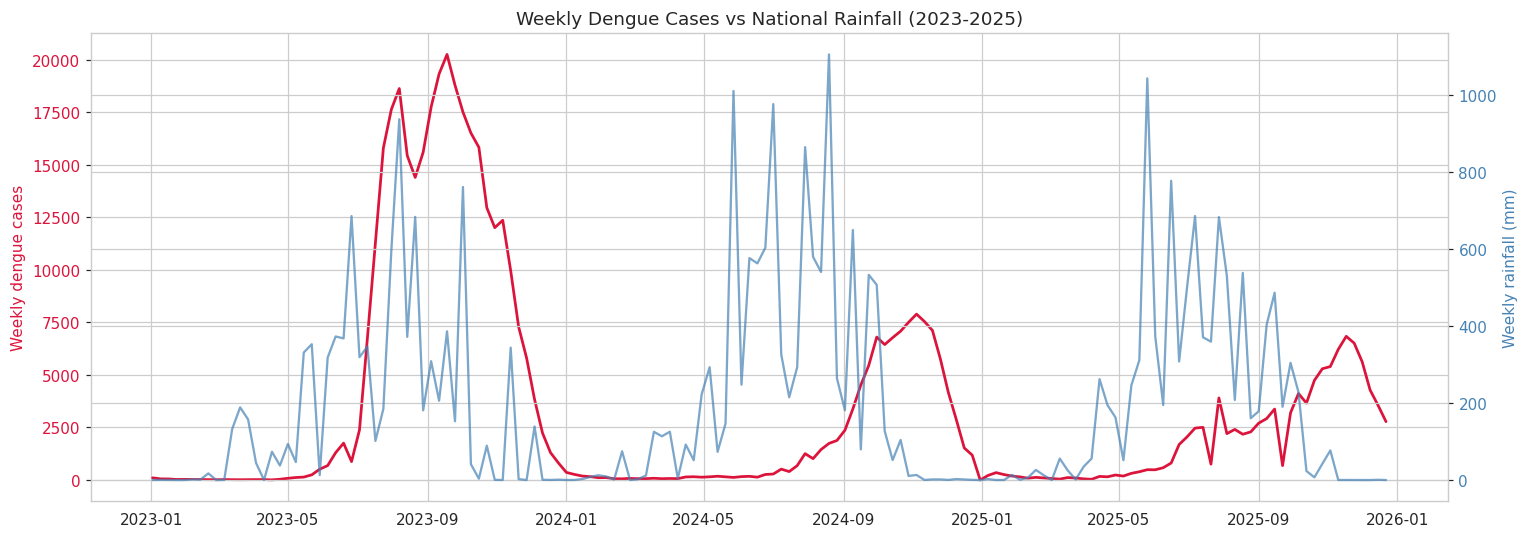

In [28]:
fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(merged['week_start'], merged['dengue_cases'], color='crimson', linewidth=1.8, label='Dengue cases')
ax1.set_ylabel('Weekly dengue cases', color='crimson')
ax1.tick_params(axis='y', labelcolor='crimson')

ax2 = ax1.twinx()
ax2.plot(merged['week_start'], merged['total_rain'], color='steelblue', alpha=0.7, label='Total rainfall (mm)')
ax2.set_ylabel('Weekly rainfall (mm)', color='steelblue')
ax2.tick_params(axis='y', labelcolor='steelblue')

ax1.set_title('Weekly Dengue Cases vs National Rainfall (2023-2025)')
plt.tight_layout()
if SAVE_FIGS:
    plt.savefig(os.path.join(FIG_DIR, 'fig6_dengue_vs_rain.png'), dpi=150)
plt.show()


## 10. Table & Figure 7 — Lagged correlation between weather and dengue cases

Since mosquito breeding and disease incubation take time, weather at week *t* is expected to relate more strongly to dengue cases several weeks later. This checks correlation at lags of 0, 1, 2, 4, and 8 weeks — matching your proposed forecasting horizons.

In [29]:
lags = [0, 1, 2, 4, 8]
rows = []
for lag in lags:
    future_cases = merged['dengue_cases'].shift(-lag)
    rows.append({
        'lag_weeks': lag,
        'rain_corr': merged['total_rain'].corr(future_cases),
        'temp_corr': merged['avg_temp'].corr(future_cases),
        'humidity_corr': merged['avg_humidity'].corr(future_cases),
    })

table7 = pd.DataFrame(rows).round(3)
print('Table 7. Correlation between current-week weather and dengue cases N weeks later')
display(table7)
table7.to_csv(os.path.join(FIG_DIR, 'table7_lag_correlation.csv'), index=False)


Table 7. Correlation between current-week weather and dengue cases N weeks later


,lag_weeks,rain_corr,temp_corr,humidity_corr
0,0,0.132,0.213,0.294
1,1,0.150,0.277,0.319
2,2,0.188,0.328,0.360
3,4,0.318,0.397,0.450
4,8,0.403,0.480,0.435


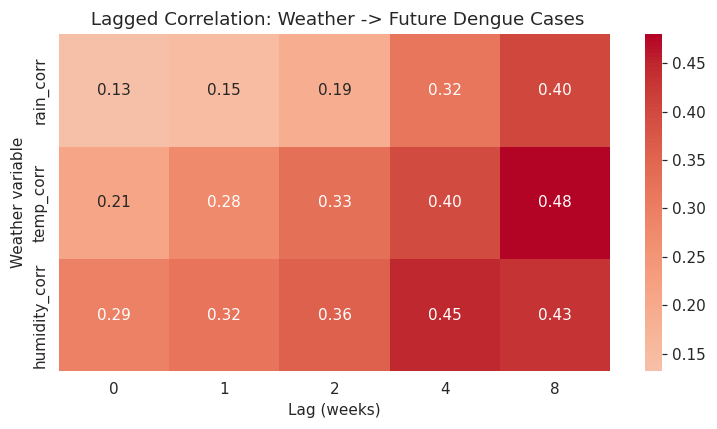

In [30]:
fig, ax = plt.subplots(figsize=(7, 4))
heat = table7.set_index('lag_weeks')[['rain_corr', 'temp_corr', 'humidity_corr']]
sns.heatmap(heat.T, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title(' Lagged Correlation: Weather -> Future Dengue Cases')
ax.set_xlabel('Lag (weeks)')
ax.set_ylabel('Weather variable')
plt.tight_layout()
if SAVE_FIGS:
    plt.savefig(os.path.join(FIG_DIR, 'fig7_lag_correlation_heatmap.png'), dpi=150)
plt.show()


## 11. Data-quality / completeness summary table (for the paper's Data section)

In [31]:
quality_rows = []
for name, df in dengue.items():
    quality_rows.append({
        'dataset': name,
        'rows': len(df),
        'date_range': f"{df.filter(like='year').min().min()}-{df.filter(like='year').max().max()}" if 'year' in df.columns else 'n/a',
        'missing_values': int(df.isnull().sum().sum()),
    })
quality_rows.append({'dataset': 'weather_hourly', 'rows': len(weather),
                      'date_range': f"{weather['time'].min().date()} to {weather['time'].max().date()}",
                      'missing_values': int(weather.isnull().sum().sum())})

table_quality = pd.DataFrame(quality_rows)
print('Table 8. Dataset completeness summary')
display(table_quality)
table_quality.to_csv(os.path.join(FIG_DIR, 'table8_data_quality_summary.csv'), index=False)


Table 8. Dataset completeness summary


,dataset,rows,date_range,missing_values
0,annual,9,2018-2026,0
1,monthly,36,2023-2025,0
2,weekly,156,2023-2025,0
3,daily_2026,154,n/a,0
4,division_2026,8,2026-2026,0
5,weekly_division_2026,176,2026-2026,0
6,weather_hourly,350880,2015-12-31 to 2026-01-01,0


## 12. Save cleaned & merged datasets for Notebook 2

These are the exact files Notebook 2 (baseline + deep learning forecasting) will load.

In [33]:
import os

os.makedirs(OUTPUT_DIR, exist_ok=True)
dengue['weekly'].to_csv(os.path.join(OUTPUT_DIR, 'dengue_weekly_national_clean.csv'), index=False)
dengue['monthly'].to_csv(os.path.join(OUTPUT_DIR, 'dengue_monthly_national_clean.csv'), index=False)
dengue['annual'].to_csv(os.path.join(OUTPUT_DIR, 'dengue_annual_national_clean.csv'), index=False)
dengue['division_2026'].to_csv(os.path.join(OUTPUT_DIR, 'dengue_division_2026_clean.csv'), index=False)
dengue['weekly_division_2026'].to_csv(os.path.join(OUTPUT_DIR, 'dengue_weekly_division_2026_clean.csv'), index=False)
weekly_weather.to_csv(os.path.join(OUTPUT_DIR, 'weather_weekly_national.csv'), index=False)
merged.to_csv(os.path.join(OUTPUT_DIR, 'dengue_weather_weekly_merged.csv'), index=False)

print('Saved cleaned files to:', OUTPUT_DIR)
print(os.listdir(OUTPUT_DIR))

Saved cleaned files to: /content/drive/MyDrive/My Work/Research/Medical_sector/Dengue/dataset/processed
['dengue_weekly_national_clean.csv', 'dengue_monthly_national_clean.csv', 'dengue_annual_national_clean.csv', 'dengue_division_2026_clean.csv', 'dengue_weekly_division_2026_clean.csv', 'weather_weekly_national.csv', 'dengue_weather_weekly_merged.csv']


## 13. Summary of findings so far (for the paper's EDA subsection)

- **Strong seasonality**: cases concentrate in the monsoon months (roughly June-October), visible in both Figure 2 and Figure 3.
- **2023 was an outlier outbreak** (321,017 cases vs a 2018-2025 average far lower) — worth flagging as a candidate for separate treatment (e.g., an outbreak-year indicator feature) rather than assuming stationarity.
- **2020 shows a sharp artificial dip** consistent with COVID-19 lockdown effects on hospital admissions/reporting, not a true epidemiological signal — consider excluding or down-weighting 2020 in training.
- **Rainfall shows the expected lagged relationship** with case counts (check Table 7/Figure 7 output above for the exact lag that correlates most strongly in this data — fill in the actual observed lag once you've run this cell).
- **Division-level granularity is currently limited to 2026 (~6 months)** — not enough to train a division-level forecaster; Notebook 2 will build the primary model at **national weekly resolution (2023-2025)** and treat division-level analysis as descriptive/risk-ranking only, consistent with the scoping decision discussed earlier in this project.

---

### Next: Notebook 2
Notebook 2 will pick up from `OUTPUT_DIR` above and cover:
1. Feature engineering (lags, rolling weather windows, Eid/holiday calendar feature, seasonal encodings)
2. Baseline models: XGBoost / LightGBM
3. Deep learning models: LSTM/GRU, Temporal Fusion Transformer, PatchTST
4. Multi-horizon forecasting (1, 2, 4, 8 weeks ahead) with MAE/RMSE/MAPE and calibration
5. Uncertainty estimation

Once you've run this notebook end-to-end in Colab, let me know and I'll give you Notebook 2.
